In [81]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer.pitch import Pitch,VerticalPitch
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

In [82]:
response=requests.get("https://www.sofascore.com/football/match/barcelona-newcastle-united/Osrgb#id:15631347,tab:statistics")

In [83]:
response.status_code

200

In [84]:
soup=BeautifulSoup(response.text,"html.parser")

In [85]:
soup.select('g[cursor="pointer"]')

[]

In [86]:
response.status_code

200

In [87]:
headers = {
    'accept': '*/*',
    'accept-language': 'en-US,en;q=0.9,hi;q=0.8',
    'referer': 'https://www.sofascore.com/football/match/barcelona-newcastle-united/Osrgb',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36',
}

url='https://www.sofascore.com/api/v1/event/15631347/shotmap'

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [88]:
shots=response.json()

In [89]:
df1=pd.json_normalize(shots["shotmap"])

In [90]:
df1

,isHome,shotType,goalType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,...,draw.end.y,draw.goal.x,draw.goal.y,player.firstName,player.lastName,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y
0,False,goal,penalty,penalty,left-foot,low-left,0.788400,0.787006,6866372,90,...,0,46.8,97.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,block,NaN,set-piece,right-foot,low-centre,0.018990,0.000000,6866363,90,...,0,51.0,81.0,,,22.5,51.8,0.0,51.8,22.5
2,True,goal,regular,assisted,right-foot,low-left,0.579359,0.903460,6866306,86,...,0,46.0,91.8,,,NaN,NaN,NaN,NaN,NaN
3,False,miss,NaN,assisted,right-foot,left,0.040006,0.000000,6866301,84,...,0,39.8,94.4,NaN,NaN,6.6,40.8,0.0,40.8,6.6
4,True,block,NaN,corner,left-foot,high-centre,0.038408,0.000000,6866276,80,...,0,49.4,79.2,NaN,NaN,9.2,36.5,0.0,36.5,9.2
5,True,block,NaN,assisted,right-foot,low-right,0.041252,0.000000,6866266,79,...,0,53.9,81.0,,,10.2,35.6,0.0,35.6,10.2
6,True,post,NaN,fast-break,right-foot,right,0.082520,0.000000,6866249,74,...,0,55.3,83.5,,,NaN,NaN,NaN,NaN,NaN
7,True,miss,NaN,throw-in-set-piece,left-foot,high,0.086953,0.000000,6866237,69,...,0,53.8,16.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,False,miss,NaN,assisted,right-foot,right,0.201422,0.000000,6866220,66,...,0,60.3,93.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,True,block,NaN,assisted,right-foot,low-right,0.073866,0.000000,6866221,66,...,0,52.3,94.4,,,14.0,50.9,0.0,50.9,14.0


In [91]:
df1=df1[["isHome","shotType","xg","time","player.shortName","player.jerseyNumber","playerCoordinates.x","playerCoordinates.y",
        "goalMouthCoordinates.x","goalMouthCoordinates.y"]]

In [92]:
df1

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,False,goal,0.788400,90,L. Yamal,10,11.5,50.0,0,53.2
1,True,block,0.018990,90,V. Livramento,21,30.6,52.1,0,49.0
2,True,goal,0.579359,86,H. Barnes,11,6.4,48.7,0,54.0
3,False,miss,0.040006,84,M. Rashford,14,17.6,42.5,0,60.2
4,True,block,0.038408,80,J. Ramsey,41,11.6,33.6,0,50.6
5,True,block,0.041252,79,H. Barnes,11,10.9,34.3,0,46.1
6,True,post,0.082520,74,H. Barnes,11,13.4,34.0,0,44.7
7,True,miss,0.086953,69,J. Murphy,23,9.8,58.7,0,46.2
8,False,miss,0.201422,66,R. Lewandowski,9,10.2,40.5,0,39.7
9,True,block,0.073866,66,S. Tonali,8,17.8,51.3,0,47.7


In [93]:
df1["playerCoordinates.x"]=df1["playerCoordinates.x"]*1.2
df1["playerCoordinates.y"]=df1["playerCoordinates.y"]*0.8
df1["goalMouthCoordinates.x"]=df1["goalMouthCoordinates.x"]*1.2
df1["goalMouthCoordinates.y"]=df1["goalMouthCoordinates.y"]*0.8

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\3066603430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["playerCoordinates.x"]=df1["playerCoordinates.x"]*1.2
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\3066603430.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["playerCoordinates.y"]=df1["playerCoordinates.y"]*0.8
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\3066603430.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

In [94]:
df1

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,False,goal,0.788400,90,L. Yamal,10,13.80,40.00,0.0,42.56
1,True,block,0.018990,90,V. Livramento,21,36.72,41.68,0.0,39.20
2,True,goal,0.579359,86,H. Barnes,11,7.68,38.96,0.0,43.20
3,False,miss,0.040006,84,M. Rashford,14,21.12,34.00,0.0,48.16
4,True,block,0.038408,80,J. Ramsey,41,13.92,26.88,0.0,40.48
5,True,block,0.041252,79,H. Barnes,11,13.08,27.44,0.0,36.88
6,True,post,0.082520,74,H. Barnes,11,16.08,27.20,0.0,35.76
7,True,miss,0.086953,69,J. Murphy,23,11.76,46.96,0.0,36.96
8,False,miss,0.201422,66,R. Lewandowski,9,12.24,32.40,0.0,31.76
9,True,block,0.073866,66,S. Tonali,8,21.36,41.04,0.0,38.16


In [95]:
for x in range(len(df1["playerCoordinates.x"])):
    if (df1["isHome"][x]==False):
        df1["playerCoordinates.y"][x]=80 - df1["playerCoordinates.y"][x]
    if (df1["isHome"][x]==True):
        df1["playerCoordinates.y"][x]=80 - df1["playerCoordinates.y"][x]

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\3691851212.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df1["playerCoordinates.y"][x]=80 - df1["playerCoordinates.y"][x]
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_157

In [96]:
df1

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,False,goal,0.788400,90,L. Yamal,10,13.80,40.00,0.0,42.56
1,True,block,0.018990,90,V. Livramento,21,36.72,38.32,0.0,39.20
2,True,goal,0.579359,86,H. Barnes,11,7.68,41.04,0.0,43.20
3,False,miss,0.040006,84,M. Rashford,14,21.12,46.00,0.0,48.16
4,True,block,0.038408,80,J. Ramsey,41,13.92,53.12,0.0,40.48
5,True,block,0.041252,79,H. Barnes,11,13.08,52.56,0.0,36.88
6,True,post,0.082520,74,H. Barnes,11,16.08,52.80,0.0,35.76
7,True,miss,0.086953,69,J. Murphy,23,11.76,33.04,0.0,36.96
8,False,miss,0.201422,66,R. Lewandowski,9,12.24,47.60,0.0,31.76
9,True,block,0.073866,66,S. Tonali,8,21.36,38.96,0.0,38.16


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

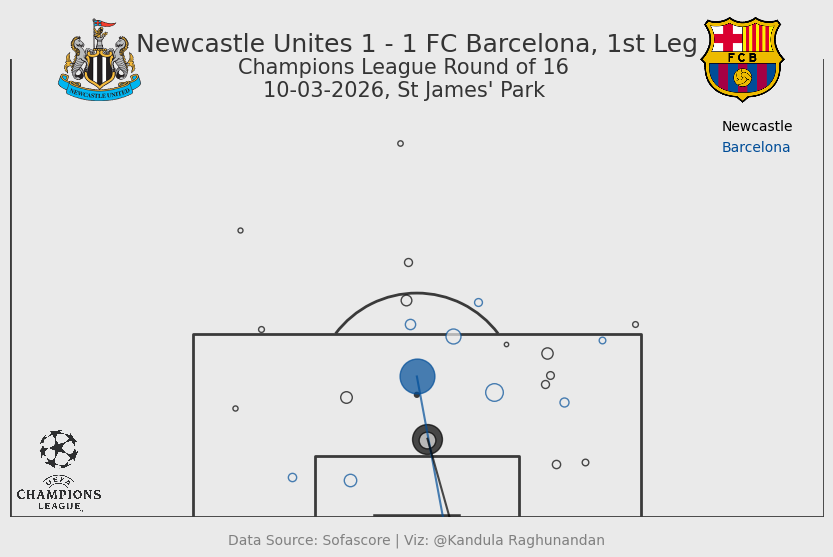

In [97]:
fig, ax=plt.subplots(figsize=(10.5,7))
fig.set_facecolor("#EAEAEA")
ax.patch.set_facecolor("#EAEAEA")

pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A',half=True)
pitch.draw(ax=ax, constrained_layout=True, tight_layout=False)
plt.gca().invert_yaxis()

home_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Newcastle.png")
away_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Barcelona.png")
league_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/UCL Logo1.png")

def add_logo(ax, img, zoom, xy):
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, xy, frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

ax.set_xlim(0,80)
ax.set_ylim(0,45)

for x in range(len(df1["playerCoordinates.x"])):
    if (df1["isHome"][x]==True):
        if df1["shotType"][x]=="save":
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#EAEAEA",s=df1["xg"][x]*800,edgecolors="#000000",alpha=0.7)
        if ((df1["shotType"][x]=="miss") | (df1["shotType"][x]=="post")):
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#EAEAEA",s=df1["xg"][x]*800,edgecolors="#000000",alpha=0.7)
        if df1["shotType"][x]=="block":
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#EAEAEA",s=df1["xg"][x]*800,edgecolors="#000000",alpha=0.7)
        if df1["shotType"][x]=="goal":
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#000000",s=df1["xg"][x]*800,edgecolors="#000000",alpha=0.7)
            plt.plot((df1["playerCoordinates.y"][x],df1["goalMouthCoordinates.y"][x]),(df1["playerCoordinates.x"][x],df1["goalMouthCoordinates.x"][x]),color="#000000",alpha=0.7)
    if (df1["isHome"][x]==False):
        if df1["shotType"][x]=="save":
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#EAEAEA",s=df1["xg"][x]*800,edgecolors="#004D98",alpha=0.7)
        if ((df1["shotType"][x]=="miss") | (df1["shotType"][x]=="post")):
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#EAEAEA",s=df1["xg"][x]*800,edgecolors="#004D98",alpha=0.7)
        if df1["shotType"][x]=="block":
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#EAEAEA",s=df1["xg"][x]*800,edgecolors="#004D98",alpha=0.7)
        if df1["shotType"][x]=="goal":
            plt.scatter(y=df1["playerCoordinates.x"][x],x=df1["playerCoordinates.y"][x],color="#004D98",s=df1["xg"][x]*800,edgecolors="#004D98",alpha=0.7)
            plt.plot((df1["playerCoordinates.y"][x],df1["goalMouthCoordinates.y"][x]),(df1["playerCoordinates.x"][x],df1["goalMouthCoordinates.x"][x]),color="#004D98",alpha=0.7)

plt.title("Newcastle Unites 1 - 1 FC Barcelona, 1st Leg",color="#343434",size=18, y=1)
plt.suptitle("Champions League Round of 16\n10-03-2026, St James' Park", fontsize=15, color="#343434", y=0.825)

ax.text(70,38,"Newcastle",c="#000000")
ax.text(70,36,"Barcelona",c="#004D98")

add_logo(ax, home_logo, zoom=0.25, xy=(0.11, 1))
add_logo(ax, away_logo, zoom=0.25, xy=(0.90, 1))
add_logo(ax,league_logo,zoom=0.03, xy=(0.06,0.1))

plt.text(
    0.5, -0.05, "Data Source: Sofascore | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="gray"
)

plt.savefig(r"C:\Users\K Raghunandan\Analyst\Matches\Newcastle 1-1 Barcelona - Champions League 2025_2026 Live_files\New folder\shot.png",bbox_inches='tight')

In [98]:
df1=df1.sort_values("time").reset_index()
df1

,index,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,24,True,block,0.017125,3,J. Ramsey,41,10.68,22.08,0.0,40.08
1,23,True,save,0.012431,4,S. Tonali,8,17.04,48.80,0.0,38.08
2,22,True,block,0.044352,6,W. Osula,18,5.16,53.68,0.0,43.28
3,21,False,block,0.028512,13,Raphinha,11,17.40,58.16,0.0,39.44
4,20,False,miss,0.068633,20,R. Araújo,4,18.96,39.28,0.0,35.52
5,19,False,miss,0.044676,23,L. Yamal,10,3.96,27.68,0.0,35.20
6,18,True,miss,0.179083,27,W. Osula,18,7.56,41.04,0.0,44.08
7,17,True,save,0.016064,33,A. Elanga,20,28.20,22.64,0.0,42.64
8,15,False,save,0.145184,36,F. López,16,17.76,43.52,0.0,40.16
9,16,False,block,0.052647,36,J. Cancelo,2,11.28,54.48,0.0,38.32


In [99]:
a_xG=[0]
h_xG=[0]
a_min=[0]
h_min=[0]

for x in range(len(df1["playerCoordinates.x"])):
    if (df1["isHome"][x]==True):
        h_xG.append(df1["xg"][x])
        h_min.append(df1["time"][x])
    if (df1["isHome"][x]==False):
        a_xG.append(df1["xg"][x])
        a_min.append(df1["time"][x])

In [100]:
def nums_cumulative_sum(nums_list):
    return [sum(nums_list[:i+1]) for i in range(len(nums_list))]

a_cum=nums_cumulative_sum(a_xG)
h_cum=nums_cumulative_sum(h_xG)

In [101]:
h_cum

[0,
 np.float64(0.017125226557255),
 np.float64(0.029556426219642),
 np.float64(0.073908626101911),
 np.float64(0.252991302870211),
 np.float64(0.269055512733755),
 np.float64(0.291032117791471),
 np.float64(0.319448956288394),
 np.float64(0.34076253604143497),
 np.float64(0.381959768943485),
 np.float64(0.455825793556865),
 np.float64(0.5427788821980319),
 np.float64(0.6252987934276419),
 np.float64(0.666551089845594),
 np.float64(0.7049591569229919),
 np.float64(1.2843176750466219),
 np.float64(1.3033073125407089)]

In [102]:
a_cum

[0,
 np.float64(0.028512086719275),
 np.float64(0.09714466705918401),
 np.float64(0.141820825636388),
 np.float64(0.287004850804808),
 np.float64(0.33965174108743895),
 np.float64(0.439722336828709),
 np.float64(0.641144715249539),
 np.float64(0.681151024997235),
 np.float64(1.469551024997235)]

In [103]:
a_total=round(a_cum[-1],2)
h_total=round(h_cum[-1],2)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

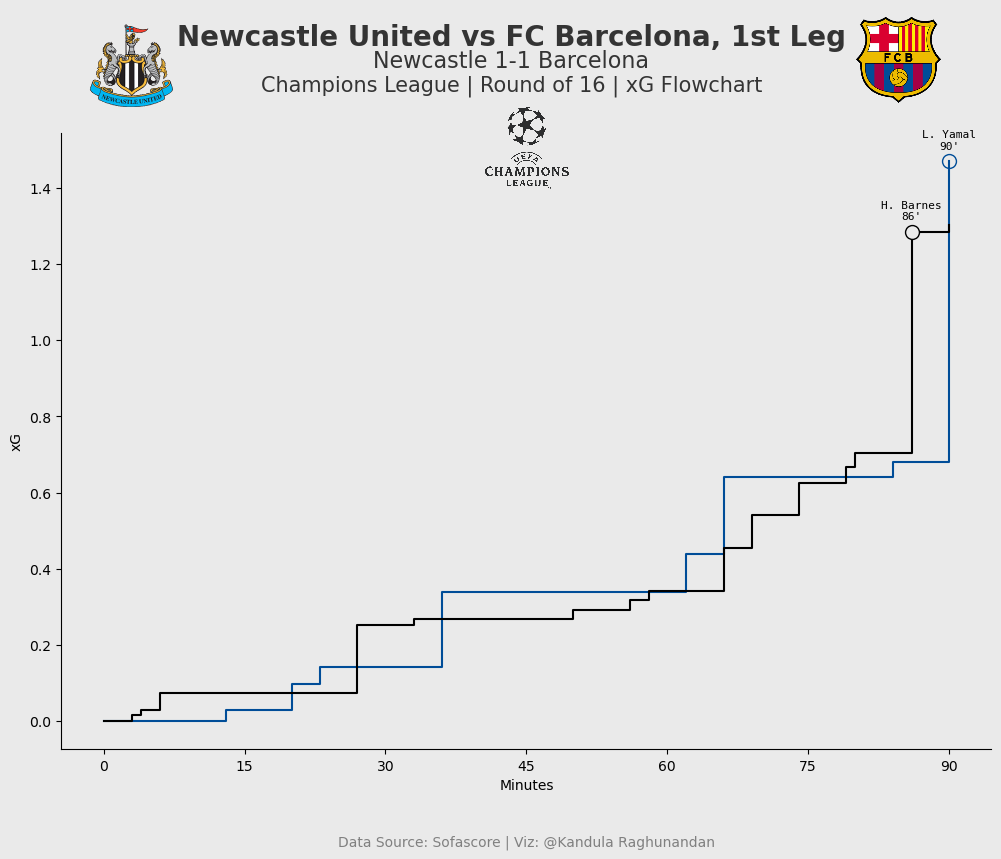

In [104]:
fig,ax=plt.subplots(figsize=(12,8))
fig.set_facecolor("#EAEAEA")
ax.patch.set_facecolor("#EAEAEA")

plt.xticks([0,15,30,45,60,75,90])
plt.xlabel("Minutes")
plt.ylabel("xG")

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

df1['cumulative_xG'] = df1.groupby('isHome')['xg'].cumsum()

ax.step(x=a_min,y=a_cum,where="post",color="#004D98")
ax.step(x=h_min,y=h_cum,where="post",color="#000000")

for x in range(len(df1["playerCoordinates.x"])):
    if (df1["isHome"][x]==True):
        if df1["shotType"][x]=="goal":
            plt.scatter(y=df1["cumulative_xG"][x],x=df1["time"][x],color="#EAEAEA",s=100,edgecolors="#000000",zorder=5)
            ax.text(
                df1['time'][x],
                df1['cumulative_xG'][x] + 0.07,
                df1['player.shortName'][x],
                ha='center',
                va='center',
                fontfamily='monospace',
                fontsize=8,
                zorder=10
            )
            ax.text(
                df1['time'][x],
                df1['cumulative_xG'][x] + 0.04,
                str(df1['time'][x])+"'",
                ha='center',
                va='center',
                fontfamily='monospace',
                fontsize=8,
                zorder=10
            )
    if (df1["isHome"][x]==False):
        if df1["shotType"][x]=="goal":
            plt.scatter(y=df1["cumulative_xG"][x],x=df1["time"][x],color="#EAEAEA",s=100,edgecolors="#004D98")
            ax.text(
                df1['time'][x],
                df1['cumulative_xG'][x] + 0.07,
                df1['player.shortName'][x],
                ha='center',
                va='center',
                fontfamily='monospace',
                fontsize=8,
                zorder=10
            )
            ax.text(
                df1['time'][x],
                df1['cumulative_xG'][x] + 0.04,
                str(df1['time'][x])+"'",
                ha='center',
                va='center',
                fontfamily='monospace',
                fontsize=8,
                zorder=10
            )

fig.text(0.5, 1, "Newcastle United vs FC Barcelona, 1st Leg", fontsize=20, fontweight='bold', color='#343434', ha="center", va="center")
fig.text(0.5, 0.97, "Newcastle 1-1 Barcelona", fontsize=16, color='#343434', ha="center", va="center")
fig.text(0.5, 0.94, "Champions League | Round of 16 | xG Flowchart", fontsize=15, color='#343434', ha="center", va="center" )

home_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Newcastle.png")
away_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Barcelona.png")
league_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/UCL Logo1.png")

def add_logo(ax, img, zoom, xy):
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, xy, frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

add_logo(ax, home_logo, zoom=0.25, xy=(0.075, 1.11))
add_logo(ax, away_logo, zoom=0.25, xy=(0.9, 1.12))
add_logo(ax, league_logo, zoom=0.03, xy=(.5, 0.975))

plt.text(
    0.5, -0.15, "Data Source: Sofascore | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="gray"
)

plt.savefig(r"C:\Users\K Raghunandan\Analyst\Matches\Newcastle 1-1 Barcelona - Champions League 2025_2026 Live_files\New folder\xG_flow.png",bbox_inches='tight')

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import requests
from bs4 import BeautifulSoup
from urllib.request import urlopen
import os
import time
from unidecode import unidecode
import warnings
from mplsoccer.pitch import Pitch
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [106]:
match_html_path = r"C:\Users\K Raghunandan\Analyst\Matches\Newcastle 1-1 Barcelona - Champions League 2025_2026 Live.html"
fotmob_matchId = 5205733

def extract_json_from_html(html_path, save_output=False):
    with open(html_path, 'r', encoding='utf-8') as html_file:
        html = html_file.read()

    regex_pattern = r'(?<=require\.config\.params\["args"\].=.)[\s\S]*?;'
    data_txt = re.findall(regex_pattern, html)[0]

    # add quotations for JSON parser
    data_txt = data_txt.replace('matchId', '"matchId"')
    data_txt = data_txt.replace('matchCentreData', '"matchCentreData"')
    data_txt = data_txt.replace('matchCentreEventTypeJson', '"matchCentreEventTypeJson"')
    data_txt = data_txt.replace('formationIdNameMappings', '"formationIdNameMappings"')
    data_txt = data_txt.replace('};', '}')

    if save_output:
        # save JSON data to txt
        output_file = open(f"{html_path}.txt", "wt", encoding='utf-8')
        n = output_file.write(data_txt)
        output_file.close()

    return data_txt

def extract_data_from_dict(data):
    # load data from json
    event_types_json = data["matchCentreEventTypeJson"]
    formation_mappings = data["formationIdNameMappings"]
    events_dict = data["matchCentreData"]["events"]
    teams_dict = {data["matchCentreData"]['home']['teamId']: data["matchCentreData"]['home']['name'],
                  data["matchCentreData"]['away']['teamId']: data["matchCentreData"]['away']['name']}
    players_dict = data["matchCentreData"]["playerIdNameDictionary"]
    # create players dataframe
    players_home_df = pd.DataFrame(data["matchCentreData"]['home']['players'])
    players_home_df["teamId"] = data["matchCentreData"]['home']['teamId']
    players_away_df = pd.DataFrame(data["matchCentreData"]['away']['players'])
    players_away_df["teamId"] = data["matchCentreData"]['away']['teamId']
    players_df = pd.concat([players_home_df, players_away_df])
    players_ids = data["matchCentreData"]["playerIdNameDictionary"]
    return events_dict, players_df, teams_dict

def get_short_name(full_name):
    if pd.isna(full_name):
        return full_name
    parts = full_name.split()
    if len(parts) == 1:
        return full_name  # No need for short name if there's only one word
    elif len(parts) == 2:
        return parts[0][0] + ". " + parts[1]
    else:
        return parts[0][0] + ". " + parts[1][0] + ". " + " ".join(parts[2:])

json_data_txt = extract_json_from_html(match_html_path)
data = json.loads(json_data_txt)
events_dict, players_df, teams_dict = extract_data_from_dict(data)

df = pd.DataFrame(events_dict)
dfp = pd.DataFrame(players_df)
dfp['shortName'] = dfp['name'].apply(get_short_name)

In [107]:
df['type'] = df['type'].str.extract(r"'displayName': '([^']+)")
df['outcomeType'] = df['outcomeType'].str.extract(r"'displayName': '([^']+)")
df['period'] = df['period'].str.extract(r"'displayName': '([^']+)")

In [108]:
df['teamName'] = df['teamId'].map(teams_dict)
team_names = list(teams_dict.values())
opposition_dict = {team_names[i]: team_names[1-i] for i in range(len(team_names))}
df['oppositionTeamName'] = df['teamName'].map(opposition_dict)

In [109]:
df['x'] = df['x']*1.2
df['y'] = df['y']*0.8
df['endX'] = df['endX']*1.2
df['endY'] = df['endY']*0.8
df['goalMouthY'] = df['goalMouthY']*0.8

In [110]:
columns_to_drop = ['height', 'weight', 'age', 'isManOfTheMatch', 'field', 'stats', 
                   'subbedInPlayerId', 'subbedOutPeriod', 
                   'subbedOutExpandedMinute', 'subbedInPeriod', 'subbedInExpandedMinute', 'subbedOutPlayerId', 
                   'teamId']
dfp.drop(columns=columns_to_drop, inplace=True)

In [111]:
df = df.merge(dfp, on='playerId', how='left')

In [112]:
df

,id,eventId,minute,second,teamId,x,y,expandedMinute,period,type,...,isShot,cardType,isGoal,teamName,oppositionTeamName,shirtNo,name,position,isFirstEleven,shortName
0,2.909854e+09,2,0,0.0,65,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,NaN,NaN,NaN,NaN,NaN
1,2.909854e+09,2,0,0.0,23,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,Newcastle,Barcelona,NaN,NaN,NaN,NaN,NaN
2,2.909854e+09,3,0,0.0,65,59.88,40.16,0,NaN,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,16.0,Fermín López,AMC,True,F. López
3,2.909854e+09,4,0,3.0,65,27.48,46.80,0,NaN,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,13.0,Joan García,GK,True,J. García
4,2.909854e+09,3,0,5.0,23,46.44,14.72,0,NaN,NaN,...,NaN,NaN,NaN,Newcastle,Barcelona,41.0,Jacob Ramsey,MC,True,J. Ramsey
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,2.909931e+09,813,96,13.0,65,0.00,0.00,98,NaN,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,NaN,NaN,NaN,NaN,NaN
1406,2.909931e+09,738,0,0.0,23,0.00,0.00,8,NaN,NaN,...,NaN,NaN,NaN,Newcastle,Barcelona,NaN,NaN,NaN,NaN,NaN
1407,2.909931e+09,814,0,0.0,65,0.00,0.00,8,NaN,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,NaN,NaN,NaN,NaN,NaN
1408,2.909817e+09,1,0,0.0,23,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,Newcastle,Barcelona,NaN,NaN,NaN,NaN,NaN


In [113]:
dfp

,playerId,shirtNo,name,position,isFirstEleven,shortName
0,316858,32,Aaron Ramsdale,GK,True,A. Ramsdale
1,83078,2,Kieran Trippier,DR,True,K. Trippier
2,393355,12,Malick Thiaw,DC,True,M. Thiaw
3,82277,33,Dan Burn,DC,True,D. Burn
4,430294,3,Lewis Hall,DL,True,L. Hall
5,201755,7,Joelinton,MC,True,Joelinton
6,343501,8,Sandro Tonali,MC,True,S. Tonali
7,369813,41,Jacob Ramsey,MC,True,J. Ramsey
8,413211,20,Anthony Elanga,FWR,True,A. Elanga
9,416209,18,William Osula,FW,True,W. Osula


In [114]:
df = df[
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['endX'].notna()) & 
    (df['endY'].notna())) | 
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['goalMouthY'].notna()))
]

In [115]:
df=df.reset_index()

In [116]:
df

,index,id,eventId,minute,second,teamId,x,y,expandedMinute,period,...,isShot,cardType,isGoal,teamName,oppositionTeamName,shirtNo,name,position,isFirstEleven,shortName
0,2,2.909854e+09,3,0,0.0,65,59.88,40.16,0,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,16.0,Fermín López,AMC,True,F. López
1,3,2.909854e+09,4,0,3.0,65,27.48,46.80,0,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,13.0,Joan García,GK,True,J. García
2,8,2.909854e+09,5,0,10.0,23,32.76,13.52,0,NaN,...,NaN,NaN,NaN,Newcastle,Barcelona,2.0,Kieran Trippier,DR,True,K. Trippier
3,9,2.909854e+09,6,0,12.0,65,65.16,44.40,0,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,5.0,Pau Cubarsí,DC,True,P. Cubarsí
4,12,2.909854e+09,7,0,16.0,23,33.00,42.80,0,NaN,...,NaN,NaN,NaN,Newcastle,Barcelona,33.0,Dan Burn,DC,True,D. Burn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,1391,2.909931e+09,804,94,6.0,65,63.00,48.24,96,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,11.0,Raphinha,AML,True,Raphinha
891,1392,2.909931e+09,805,94,9.0,65,79.20,67.92,96,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,18.0,Gerard Martín,DC,True,G. Martín
892,1397,2.909931e+09,809,94,15.0,65,81.12,61.28,96,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,2.0,João Cancelo,DL,True,J. Cancelo
893,1398,2.909931e+09,810,94,18.0,65,81.48,44.40,96,NaN,...,NaN,NaN,NaN,Barcelona,Newcastle,11.0,Raphinha,AML,True,Raphinha


In [117]:
df=df[["minute","second","x","y","endX","endY","teamName","shirtNo","position","shortName","goalMouthY","isShot","isGoal"]]

In [118]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,59.88,40.16,24.84,44.72,Barcelona,16.0,AMC,F. López,NaN,NaN,NaN
1,0,3.0,27.48,46.80,73.56,65.28,Barcelona,13.0,GK,J. García,NaN,NaN,NaN
2,0,10.0,32.76,13.52,57.12,36.32,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
3,0,12.0,65.16,44.40,87.00,37.20,Barcelona,5.0,DC,P. Cubarsí,NaN,NaN,NaN
4,0,16.0,33.00,42.80,48.48,66.80,Newcastle,33.0,DC,D. Burn,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,94,6.0,63.00,48.24,65.88,64.56,Barcelona,11.0,AML,Raphinha,NaN,NaN,NaN
891,94,9.0,79.20,67.92,93.00,78.32,Barcelona,18.0,DC,G. Martín,NaN,NaN,NaN
892,94,15.0,81.12,61.28,78.12,43.20,Barcelona,2.0,DL,J. Cancelo,NaN,NaN,NaN
893,94,18.0,81.48,44.40,93.84,48.72,Barcelona,11.0,AML,Raphinha,NaN,NaN,NaN


In [119]:
xT=pd.read_csv("C:/Users/K Raghunandan/OneDrive/Desktop/Raghu/Kickoff/CSV Files/xT_Grid.csv",header = None)
xT.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.006383,0.007796,0.008449,0.009777,0.011263,0.012483,0.014736,0.017451,0.021221,0.027563,0.034851,0.037926
1,0.007501,0.008786,0.009424,0.010595,0.012147,0.013845,0.016118,0.018703,0.024015,0.029533,0.040670,0.046477
2,0.008880,0.009777,0.010013,0.011105,0.012692,0.014291,0.016856,0.019351,0.024122,0.028552,0.054911,0.064426
3,0.009411,0.010827,0.010165,0.011324,0.012626,0.014846,0.016895,0.019971,0.023851,0.035113,0.108051,0.257454
4,0.009411,0.010827,0.010165,0.011324,0.012626,0.014846,0.016895,0.019971,0.023851,0.035113,0.108051,0.257454


In [120]:
xT=np.array(xT)
xT

array([[0.00638303, 0.00779616, 0.00844854, 0.00977659, 0.01126267,
        0.01248344, 0.01473596, 0.0174506 , 0.02122129, 0.02756312,
        0.03485072, 0.0379259 ],
       [0.00750072, 0.00878589, 0.00942382, 0.0105949 , 0.01214719,
        0.0138454 , 0.01611813, 0.01870347, 0.02401521, 0.02953272,
        0.04066992, 0.04647721],
       [0.0088799 , 0.00977745, 0.01001304, 0.01110462, 0.01269174,
        0.01429128, 0.01685596, 0.01935132, 0.0241224 , 0.02855202,
        0.05491138, 0.06442595],
       [0.00941056, 0.01082722, 0.01016549, 0.01132376, 0.01262646,
        0.01484598, 0.01689528, 0.0199707 , 0.02385149, 0.03511326,
        0.10805102, 0.25745362],
       [0.00941056, 0.01082722, 0.01016549, 0.01132376, 0.01262646,
        0.01484598, 0.01689528, 0.0199707 , 0.02385149, 0.03511326,
        0.10805102, 0.25745362],
       [0.0088799 , 0.00977745, 0.01001304, 0.01110462, 0.01269174,
        0.01429128, 0.01685596, 0.01935132, 0.0241224 , 0.02855202,
        0.05491138,

In [121]:
xT_rows, xT_cols = xT.shape

In [122]:
xT_rows

8

In [123]:
xT_cols

12

In [124]:
df["x1_bin"]=pd.cut(df["x"],bins=xT_cols,labels=False)
df["y1_bin"]=pd.cut(df["y"],bins=xT_rows,labels=False)
df["x2_bin"]=pd.cut(df["endX"],bins=xT_cols,labels=False)
df["y2_bin"]=pd.cut(df["endY"],bins=xT_rows,labels=False)

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\2369042483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["x1_bin"]=pd.cut(df["x"],bins=xT_cols,labels=False)
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\2369042483.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["y1_bin"]=pd.cut(df["y"],bins=xT_rows,labels=False)
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\2369042483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [125]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal,x1_bin,y1_bin,x2_bin,y2_bin
0,0,0.0,59.88,40.16,24.84,44.72,Barcelona,16.0,AMC,F. López,NaN,NaN,NaN,5,4,2.0,4.0
1,0,3.0,27.48,46.80,73.56,65.28,Barcelona,13.0,GK,J. García,NaN,NaN,NaN,2,4,7.0,6.0
2,0,10.0,32.76,13.52,57.12,36.32,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN,3,1,5.0,3.0
3,0,12.0,65.16,44.40,87.00,37.20,Barcelona,5.0,DC,P. Cubarsí,NaN,NaN,NaN,6,4,8.0,3.0
4,0,16.0,33.00,42.80,48.48,66.80,Newcastle,33.0,DC,D. Burn,NaN,NaN,NaN,3,4,4.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,94,6.0,63.00,48.24,65.88,64.56,Barcelona,11.0,AML,Raphinha,NaN,NaN,NaN,6,4,6.0,6.0
891,94,9.0,79.20,67.92,93.00,78.32,Barcelona,18.0,DC,G. Martín,NaN,NaN,NaN,7,6,9.0,7.0
892,94,15.0,81.12,61.28,78.12,43.20,Barcelona,2.0,DL,J. Cancelo,NaN,NaN,NaN,8,6,7.0,4.0
893,94,18.0,81.48,44.40,93.84,48.72,Barcelona,11.0,AML,Raphinha,NaN,NaN,NaN,8,4,9.0,4.0


In [126]:
df=df.fillna(value=0)

In [127]:
df["start_zone_value"] = xT[
    df["y1_bin"].astype(int),
    df["x1_bin"].astype(int)
]

df["end_zone_value"] = xT[
    df["y2_bin"].astype(int),
    df["x2_bin"].astype(int)
]

In [128]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal,x1_bin,y1_bin,x2_bin,y2_bin,start_zone_value,end_zone_value
0,0,0.0,59.88,40.16,24.84,44.72,Barcelona,16.0,AMC,F. López,0.00,0,0,5,4,2.0,4.0,0.014846,0.010165
1,0,3.0,27.48,46.80,73.56,65.28,Barcelona,13.0,GK,J. García,0.00,0,0,2,4,7.0,6.0,0.010165,0.018703
2,0,10.0,32.76,13.52,57.12,36.32,Newcastle,2.0,DR,K. Trippier,0.00,0,0,3,1,5.0,3.0,0.010595,0.014846
3,0,12.0,65.16,44.40,87.00,37.20,Barcelona,5.0,DC,P. Cubarsí,0.00,0,0,6,4,8.0,3.0,0.016895,0.023851
4,0,16.0,33.00,42.80,48.48,66.80,Newcastle,33.0,DC,D. Burn,0.00,0,0,3,4,4.0,6.0,0.011324,0.012147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,94,6.0,63.00,48.24,65.88,64.56,Barcelona,11.0,AML,Raphinha,0.00,0,0,6,4,6.0,6.0,0.016895,0.016118
891,94,9.0,79.20,67.92,93.00,78.32,Barcelona,18.0,DC,G. Martín,0.00,0,0,7,6,9.0,7.0,0.018703,0.027563
892,94,15.0,81.12,61.28,78.12,43.20,Barcelona,2.0,DL,J. Cancelo,0.00,0,0,8,6,7.0,4.0,0.024015,0.019971
893,94,18.0,81.48,44.40,93.84,48.72,Barcelona,11.0,AML,Raphinha,0.00,0,0,8,4,9.0,4.0,0.023851,0.035113


In [129]:
df["xT"]=df["end_zone_value"]-df["start_zone_value"]

In [130]:
df_xT = (
    df.groupby(["shortName", "teamName"])["xT"]
    .sum()
    .reset_index()
    .sort_values(by="xT", ascending=False)
)

In [131]:
df_xT

,shortName,teamName,xT
27,S. Tonali,Newcastle,1.278548
16,L. Hall,Newcastle,0.980023
26,Raphinha,Barcelona,0.895815
15,K. Trippier,Newcastle,0.888430
0,A. Elanga,Newcastle,0.556717
2,A. Ramsdale,Newcastle,0.382819
17,L. Yamal,Barcelona,0.226889
11,J. Murphy,Newcastle,0.144131
10,J. García,Barcelona,0.141159
22,P. Cubarsí,Barcelona,0.121204


In [132]:
df_xT = (
    df_xT
    .sort_values("xT", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

In [133]:
df_xT["path"]=0

In [134]:
for x in range(len(df_xT)):
    if df_xT["teamName"][x]=="Newcastle":
        df_xT["path"][x]="C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Newcastle.png"
    if df_xT["teamName"][x]=="Barcelona":
        df_xT["path"][x]="C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Barcelona.png"

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_15792\281503726.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_xT["path"][x]="C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Newcastle.png"
C:\Users\K Raghunandan\AppData\Local\Temp

In [135]:
df_xT

,shortName,teamName,xT,path
0,S. Tonali,Newcastle,1.278548,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
1,L. Hall,Newcastle,0.980023,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
2,Raphinha,Barcelona,0.895815,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
3,K. Trippier,Newcastle,0.888430,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
4,A. Elanga,Newcastle,0.556717,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
5,A. Ramsdale,Newcastle,0.382819,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
6,L. Yamal,Barcelona,0.226889,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
7,J. Murphy,Newcastle,0.144131,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
8,J. García,Barcelona,0.141159,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...
9,P. Cubarsí,Barcelona,0.121204,C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26...


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

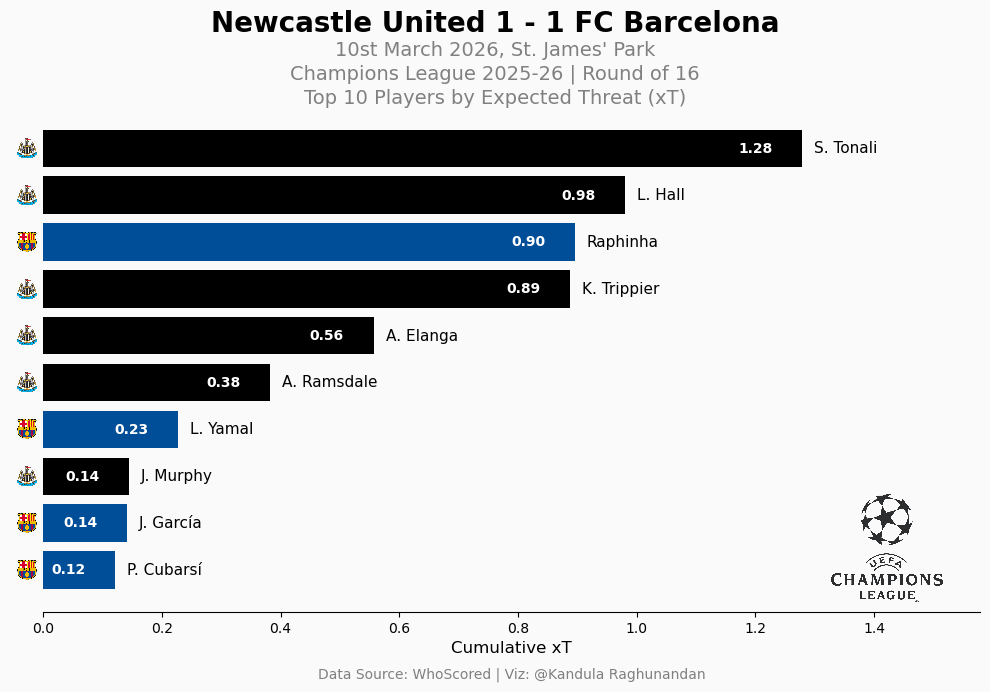

In [136]:
plt.rcParams.update({'font.family':'Avenir'})
bgcol = '#fafafa'

fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor(bgcol)
ax.set_facecolor(bgcol)

team_colors = {
    "Newcastle": "#000000",
    "Barcelona": "#004D98"
}

bar_colors = df_xT["teamName"].map(team_colors)

bars = ax.barh(
    range(len(df_xT)),
    df_xT["xT"],
    color=bar_colors
)

ax.invert_yaxis()

ax.set_yticks([])

ax.set_xlabel("Cumulative xT", fontsize=12)

ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)

for i, value in enumerate(df_xT["xT"]):
    ax.text(
        value + 0.02,
        i,
        df_xT["shortName"].iloc[i],
        va="center",
        fontsize=11
    )

for i, value in enumerate(df_xT["xT"]):
    ax.text(
        value - 0.05,             
        i,
        f"{value:.2f}",             
        va="center",
        ha="right",
        fontsize=10,
        color="white",
        weight="bold"
    )

for i, team in enumerate(df_xT["teamName"]):
    try:
        logo = mpimg.imread(df_xT["path"][i])
        imagebox = OffsetImage(logo, zoom=0.06)
        ab = AnnotationBbox(
            imagebox,
            (0, i),
            frameon=False,
            box_alignment=(1.3, 0.5)
        )
        ax.add_artist(ab)
    except FileNotFoundError:
        print(f"Logo not found for {team}")

ax.set_xlim(0, df_xT["xT"].max() + 0.3)

fig.text(0.5, 1.1,
         "Newcastle United 1 - 1 FC Barcelona",
         ha="center",
         fontsize=20,
         fontweight="bold")

fig.text(0.5, 1.06,
         "10st March 2026, St. James' Park",
         ha="center",
         fontsize=14,
         color="grey")

fig.text(0.5, 1.02,
         "Champions League 2025-26 | Round of 16",
         ha="center",
         fontsize=14,
         color="grey")

fig.text(0.5, 0.98,
         "Top 10 Players by Expected Threat (xT)",
         ha="center",
         fontsize=14,
         color="grey")

home_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Newcastle.png")
away_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/Barcelona.png")
league_logo=mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/UCL 25-26/UCL Logo1.png")

def add_logo(ax, img, zoom, xy):
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, xy, frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

#add_logo(ax, home_logo, zoom=0.18, xy=(0.05, 1))
#add_logo(ax, away_logo, zoom=0.18, xy=(0.95, 1.2))
add_logo(ax, league_logo, zoom=0.04, xy=(0.9, 0.125))

plt.text(
    0.5, -0.125, "Data Source: WhoScored | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="gray"
)

plt.tight_layout()

plt.savefig(r"C:\Users\K Raghunandan\Analyst\Matches\Newcastle 1-1 Barcelona - Champions League 2025_2026 Live_files\New folder\xT.png",bbox_inches='tight')
plt.show()